# Previsão da Nota Média de Filmes no TMDB

**Disciplina:** Aprendizado de Máquina — Universidade Federal de Sergipe
**Integrantes:** Luís Felipe Rocha Machado, Ranieri Pereira Carvalho Filho

## 5.1 Identificação e descrição do problema

**Fonte dos dados:** [The Movie Database (TMDB)](https://www.themoviedb.org/), via dataset público no Kaggle
*"Movie Dataset (1957-2026)"* (`movie_data.csv`), complementado por uma segunda extração,
`Top_rated_movies.csv`, também do TMDB.

**Objetivo:** construir um modelo capaz de **prever a nota média (`rating`) que um filme recebe no TMDB**
a partir de atributos disponíveis antes ou independentemente da nota em si (contagem de votos, idioma
original, data de lançamento, etc.), e comparar diferentes algoritmos de regressão para essa tarefa.

**Atributo-alvo:** `rating` (nota média do TMDB, 0 a 10) — variável **numérica contínua**.

**Atributos preditivos (candidatos):** `vote_count` (quantidade de votos), `original_language` (idioma
original), `release_date` / ano de lançamento, `title`/`overview` (usados para features derivadas, como
tamanho do texto), entre outros a definir na etapa de pré-processamento.

**Tipo da tarefa:** **Regressão**, pois o atributo-alvo (`rating`) representa um valor numérico contínuo,
e não uma categoria. Por isso, os modelos mínimos exigidos são regressão linear, árvore de decisão e
Random Forest (regressores).

## Imports e Configuração

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Carregamento dos Dados

Os dados são carregados diretamente do repositório público no GitHub (sem depender de arquivos locais).

> ⚠️ **TODO:** assim que o repositório do grupo estiver criado, atualizar as duas URLs abaixo para os
> links *raw* dos arquivos `movie_data.csv` e `Top_rated_movies.csv` dentro do repositório
> (ex.: `https://raw.githubusercontent.com/usuario/repo/main/data/movie_data.csv`).

In [2]:
# TODO: trocar pelas URLs "raw" do GitHub assim que o repositório existir
URL_MOVIE_DATA = "https://raw.githubusercontent.com/LFelipe-Machado/projeto-ia-FelipeMachado-RanieriPereira/main/data/movie_data.csv"
URL_TOP_RATED = "https://raw.githubusercontent.com/LFelipe-Machado/projeto-ia-FelipeMachado-RanieriPereira/main/data/Top_rated_movies.csv"

df_movies = pd.read_csv(URL_MOVIE_DATA)
df_top = pd.read_csv(URL_TOP_RATED)

print(f'movie_data.csv: {df_movies.shape[0]} linhas, {df_movies.shape[1]} colunas')
print(f'Top_rated_movies.csv: {df_top.shape[0]} linhas, {df_top.shape[1]} colunas')

movie_data.csv: 2000 linhas, 8 colunas
Top_rated_movies.csv: 10000 linhas, 9 colunas


## 5.2 Compreensão dos Dados

### Quantidade de registros, atributos e tipos das variáveis

In [3]:
print('=== movie_data.csv ===')
df_movies.info()
print()
print('=== Top_rated_movies.csv ===')
df_top.info()

=== movie_data.csv ===
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   title              2000 non-null   str    
 2   original_language  2000 non-null   str    
 3   overview           1985 non-null   str    
 4   release_date       1996 non-null   str    
 5   original_title     2000 non-null   str    
 6   vote_average       2000 non-null   float64
 7   vote_count         2000 non-null   int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 125.1 KB

=== Top_rated_movies.csv ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10000 non-null  int64  
 1   title              10000 non-null  str    
 2   original_language  

**Interpretação:** `movie_data.csv` tem 2000 registros e 8 atributos (mistura de texto, categórico e
numérico); `Top_rated_movies.csv` tem 10000 registros e 9 atributos, incluindo a coluna `popularity` que
não existe em `movie_data.csv`. As colunas `vote_average` (em `movie_data.csv`) e `rating` (em
`Top_rated_movies.csv`) representam o mesmo conceito — a nota média do filme — só que com nomes
diferentes entre as duas extrações.

### Valores ausentes

In [4]:
print('Valores ausentes — movie_data.csv:')
display(df_movies.isnull().sum())
print()
print('Valores ausentes — Top_rated_movies.csv:')
display(df_top.isnull().sum())

Valores ausentes — movie_data.csv:


id                    0
title                 0
original_language     0
overview             15
release_date          4
original_title        0
vote_average          0
vote_count            0
dtype: int64


Valores ausentes — Top_rated_movies.csv:


id                     0
title                  0
original_language      0
original_title         0
overview             500
release_date           0
popularity             0
vote_count             0
rating                 0
dtype: int64

**Interpretação:** em `movie_data.csv`, `overview` tem 15 valores ausentes (0,75%) e `release_date` tem
4 (0,2%) — volume pequeno, provavelmente filmes muito obscuros ou registros incompletos no TMDB. Em
`Top_rated_movies.csv`, apenas `overview` tem 500 valores ausentes, mas — como veremos a seguir — esse
número (500) não é coincidência: está diretamente ligado a um problema estrutural bem mais sério nesse
arquivo.

### Duplicações

In [5]:
print('movie_data.csv:')
print(f"  linhas totais: {len(df_movies)} | ids únicos: {df_movies['id'].nunique()} | linhas duplicadas (mesmo id): {df_movies.duplicated(subset='id').sum()}")
print()
print('Top_rated_movies.csv:')
print(f"  linhas totais: {len(df_top)} | ids únicos: {df_top['id'].nunique()} | linhas duplicadas (mesmo id): {df_top.duplicated(subset='id').sum()}")
print()
print('Quantas vezes cada filme se repete em Top_rated_movies.csv:')
display(df_top['id'].value_counts())

movie_data.csv:
  linhas totais: 2000 | ids únicos: 1991 | linhas duplicadas (mesmo id): 9

Top_rated_movies.csv:
  linhas totais: 10000 | ids únicos: 20 | linhas duplicadas (mesmo id): 9980

Quantas vezes cada filme se repete em Top_rated_movies.csv:


id
13448      500
9603       500
6557       500
1333100    500
578701     500
1529513    500
2502       500
9297       500
508935     500
1576198    500
1051896    500
8920       500
893694     500
21835      500
1653208    500
1401586    500
76203      500
516486     500
1137350    500
975        500
Name: count, dtype: int64

**Interpretação — achado importante:** `Top_rated_movies.csv` tem 10000 linhas, mas apenas **20 filmes
únicos**, cada um repetido **exatamente 500 vezes**. Isso não é um desbalanceamento natural dos dados: é
um artefato de coleta (provavelmente um script que paginou uma API e, por erro, salvou a mesma página
500 vezes). Isso também explica os 500 valores ausentes em `overview` vistos acima — são só 1 valor
ausente × 500 repetições.

Como consequência, **`Top_rated_movies.csv` não é utilizável para treinar um modelo**: após remover as
duplicatas, sobrariam apenas 20 observações, insuficiente para qualquer separação treino/teste
estatisticamente razoável. Por isso, a partir daqui o grupo optou por conduzir a análise e a modelagem
usando **`movie_data.csv`** como base principal, e vamos apenas comentar esse problema do
`Top_rated_movies.csv` como parte da compreensão dos dados (item exigido pelo enunciado), sem usá-lo na
modelagem.

Já em `movie_data.csv`, há apenas 9 linhas duplicadas (mesmo `id`) em 2000 — um problema real, mas
pequeno e tratável, que será removido no pré-processamento (seção 5.4).

### Inconsistências

In [6]:
zero_votes = df_movies[df_movies['vote_count'] == 0]
print(f"Filmes com vote_count == 0: {len(zero_votes)}")
print('Estatísticas de vote_average nesses filmes:')
display(zero_votes['vote_average'].describe())

print()
extreme = df_movies[(df_movies['vote_average'] == 10) & (df_movies['vote_count'] <= 1)]
print(f"Filmes com nota máxima (10.0) baseada em apenas 1 voto: {len(extreme)}")
display(extreme[['title', 'vote_average', 'vote_count']])

Filmes com vote_count == 0: 62
Estatísticas de vote_average nesses filmes:


count    62.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: vote_average, dtype: float64


Filmes com nota máxima (10.0) baseada em apenas 1 voto: 4


,title,vote_average,vote_count
75,The Last Supper,10.0,1
360,Ishqa'n De Lekhe,10.0,1
568,Solace,10.0,1
1863,Sex,10.0,1


**Interpretação:** encontramos duas inconsistências relevantes para o pré-processamento:

1. **Todo filme com `vote_count == 0` tem `vote_average` exatamente igual a `0.0`.** Isso não significa
   que o filme tem nota zero — significa que ele ainda não recebeu nenhum voto (muitos são lançamentos
   futuros de 2026-2028). Um `0.0` nesse caso é um valor "placeholder", não uma avaliação real. Manter
   essas linhas no treinamento ensinaria o modelo a associar "poucos votos" a "nota baixa", o que é um
   viés falso — na verdade não sabemos a nota desses filmes.
2. Filmes com **`vote_average == 10.0` mas apenas 1 voto** são notas extremas baseadas em uma amostra
   estatisticamente pouco confiável (uma única pessoa). São candidatos a outliers / ruído.

Essas duas inconsistências serão tratadas explicitamente na seção 5.4 (Pré-processamento).

### Distribuição do atributo-alvo (`vote_average`)

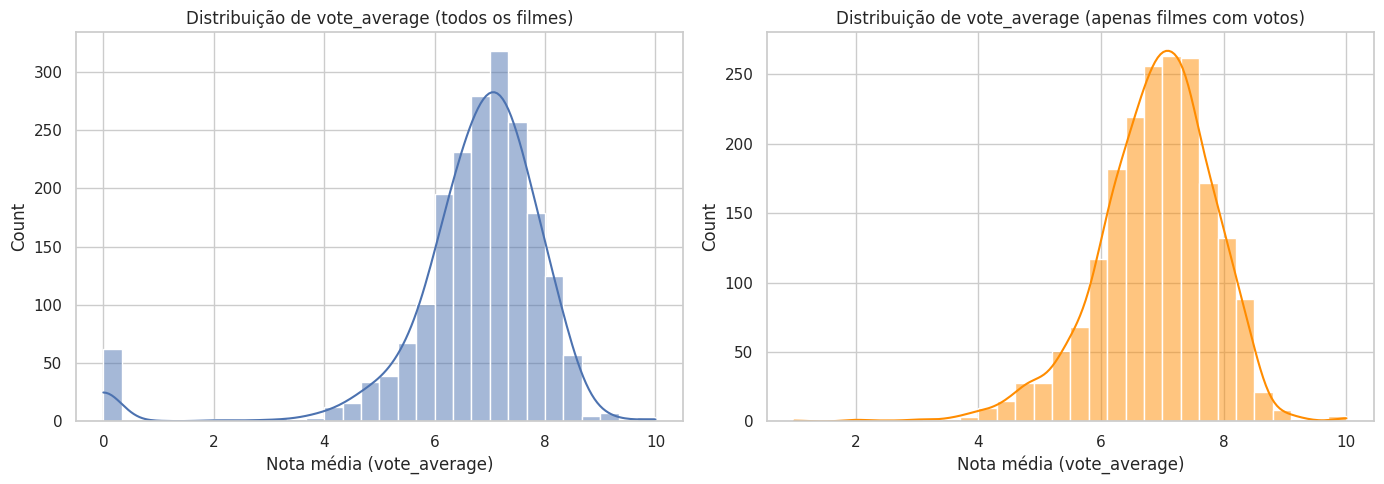

Estatísticas descritivas — todos os filmes:


count    2000.000000
mean        6.674291
std         1.515810
min         0.000000
25%         6.274750
50%         6.942500
75%         7.499250
max        10.000000
Name: vote_average, dtype: float64

Estatísticas descritivas — apenas filmes com ao menos 1 voto:


count    1938.000000
mean        6.887814
std         0.948559
min         1.000000
25%         6.365500
50%         6.973000
75%         7.508500
max        10.000000
Name: vote_average, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_movies['vote_average'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de vote_average (todos os filmes)')
axes[0].set_xlabel('Nota média (vote_average)')

released = df_movies[df_movies['vote_count'] > 0]
sns.histplot(released['vote_average'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribuição de vote_average (apenas filmes com votos)')
axes[1].set_xlabel('Nota média (vote_average)')

plt.tight_layout()
plt.show()

print('Estatísticas descritivas — todos os filmes:')
display(df_movies['vote_average'].describe())
print('Estatísticas descritivas — apenas filmes com ao menos 1 voto:')
display(released['vote_average'].describe())

**Interpretação:** no gráfico da esquerda (todos os filmes) aparece um pico artificial em 0, causado
exatamente pelos 62 filmes sem votos discutidos acima. Quando filtramos apenas filmes com pelo menos 1
voto (gráfico da direita), a distribuição fica bem mais próxima de uma normal, concentrada entre 6 e 8,
com média em torno de 6,9 e mediana em torno de 7,0 — coerente com o fato de o dataset ser majoritariamente
composto por filmes "populares o suficiente" para aparecer no TMDB com um volume razoável de votos, e não
uma amostra aleatória de todos os filmes já feitos (que teria mais notas baixas). Essa assimetria é
importante: o problema não é uma variável perfeitamente balanceada em torno da média, e o modelo tende a
ser mais preciso na faixa 6-8 (onde há mais exemplos) do que nos extremos.

### Concentração / desbalanceamento em atributos preditivos

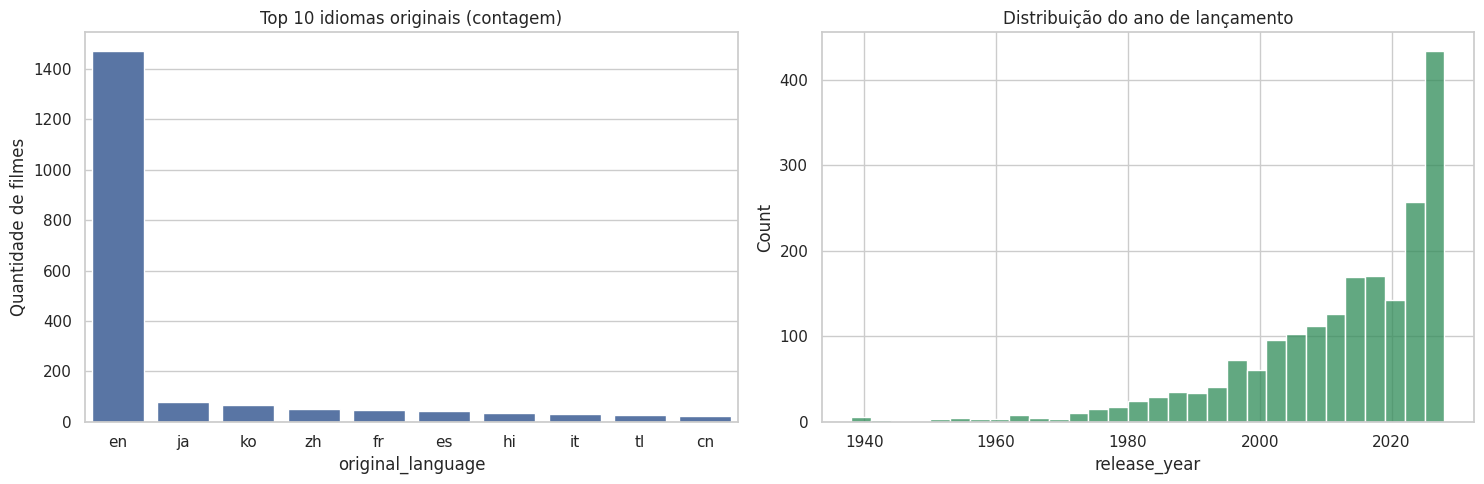

Percentual do idioma mais comum: 73.5%
Percentual de filmes lançados a partir de 2020: 39.0%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_langs = df_movies['original_language'].value_counts().head(10)
sns.barplot(x=top_langs.index, y=top_langs.values, ax=axes[0])
axes[0].set_title('Top 10 idiomas originais (contagem)')
axes[0].set_ylabel('Quantidade de filmes')

df_movies['release_year'] = pd.to_datetime(df_movies['release_date'], errors='coerce').dt.year
sns.histplot(df_movies['release_year'].dropna(), bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Distribuição do ano de lançamento')

plt.tight_layout()
plt.show()

print('Percentual do idioma mais comum:', f"{top_langs.iloc[0] / len(df_movies):.1%}")
print('Percentual de filmes lançados a partir de 2020:', f"{(df_movies['release_year'] >= 2020).mean():.1%}")

**Interpretação:** a variável categórica `original_language` é fortemente concentrada — cerca de 73% dos
filmes são em inglês (`en`), e o restante se espalha em uma longa cauda de dezenas de idiomas com poucas
observações cada. Isso é um desbalanceamento relevante: se usarmos one-hot encoding direto, teremos
muitas colunas quase sempre zero. Trataremos isso agrupando idiomas raros em uma categoria `"outro"` na
seção de pré-processamento.

Também há concentração temporal: cerca de 39% dos filmes foram lançados a partir de 2020, e o dataset
inclui até lançamentos "futuros" (2026-2028) — reforçando por que precisamos tratar `vote_count == 0`
separadamente, já que esses lançamentos futuros ainda não têm avaliação real.

## 5.3 Análise Exploratória

Como visto na seção 5.2, os 62 filmes com `vote_count == 0` têm `vote_average` artificialmente igual a
`0.0` (ainda não foram avaliados). Para as análises de relação entre atributos e o alvo abaixo, usamos
apenas os filmes que já possuem ao menos 1 voto real — caso contrário, esse pico artificial em zero
distorceria todas as medidas e gráficos. A remoção formal (com justificativa completa) será feita na
seção 5.4 (Pré-processamento); aqui usamos o filtro apenas para fins de exploração.

In [9]:
df_released = df_movies[df_movies['vote_count'] > 0].copy()
df_released['overview_length'] = df_released['overview'].fillna('').apply(len)
print(f'Filmes considerados na análise exploratória: {len(df_released)} de {len(df_movies)}')

Filmes considerados na análise exploratória: 1938 de 2000


### Medidas de localidade e dispersão

In [10]:
df_released[['vote_average', 'vote_count', 'release_year', 'overview_length']].describe()

,vote_average,vote_count,release_year,overview_length
count,1938.000000,1938.000000,1938.000000,1938.000000
mean,6.887814,5343.666151,2011.155315,264.701238
std,0.948559,6144.233557,15.329697,124.090425
min,1.000000,1.000000,1938.000000,0.000000
25%,6.365500,358.250000,2004.000000,168.250000
50%,6.973000,3503.000000,2015.000000,240.000000
75%,7.508500,7928.500000,2023.750000,339.750000
max,10.000000,39900.000000,2026.000000,987.000000


**Interpretação:** `vote_average` tem média (6,89) muito próxima da mediana (6,97), com desvio padrão
baixo (0,95) — é uma variável bem concentrada, sem grande dispersão, o que é esperado já que o TMDB tende
a "puxar" notas de filmes com poucos votos para perto da média geral (regularização bayesiana que o
próprio TMDB aplica). Já `vote_count` tem uma dispersão enorme (desvio padrão de ~6100, maior até que a
própria média) — é uma variável de cauda longa, com poucos blockbusters concentrando a maior parte dos
votos, e por isso será analisada em escala logarítmica adiante. `release_year` mostra que metade dos
filmes do dataset foi lançada depois de 2016 (mediana), reforçando o viés para produções recentes já
observado na seção 5.2.

### Tabela de frequência — idioma original

In [11]:
freq = df_released['original_language'].value_counts()
freq_pct = (freq / len(df_released) * 100).round(2)
tabela_freq = pd.DataFrame({'contagem': freq, 'percentual (%)': freq_pct})
tabela_freq.head(10)

,contagem,percentual (%)
original_language,,
en,1449,74.77
ja,70,3.61
ko,64,3.30
fr,46,2.37
zh,43,2.22
es,42,2.17
hi,31,1.60
it,30,1.55
tl,26,1.34


**Interpretação:** confirma o que já havia aparecido na seção 5.2 — inglês domina com folga (74,8%), e o
segundo colocado (japonês) fica em apenas 3,6%. Os nove idiomas seguintes somados (19,5%) não chegam a
superar o inglês sozinho. Essa tabela reforça a decisão de agrupar idiomas raros em uma categoria
`"outro"` no pré-processamento, em vez de criar dezenas de colunas one-hot quase sempre zeradas.

### Histograma — `vote_count`

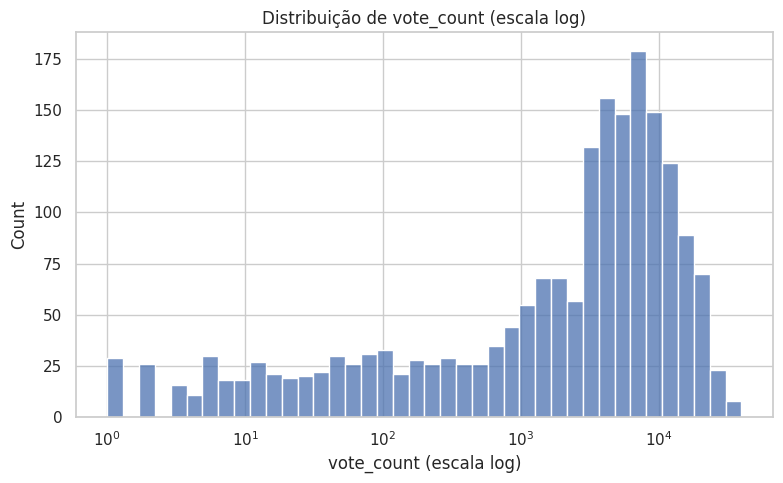

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(df_released['vote_count'], bins=40, log_scale=(True, False))
plt.title('Distribuição de vote_count (escala log)')
plt.xlabel('vote_count (escala log)')
plt.show()

**Interpretação:** em escala linear essa variável seria quase ilegível (a maioria dos filmes concentrada
perto de zero e uma cauda longuíssima de poucos filmes com dezenas de milhares de votos). Em escala log
aparece um formato bem mais próximo de uma normal, o que sugere que `log(vote_count)` pode ser uma
transformação útil para os modelos de regressão lineares na etapa de pré-processamento.

### Boxplot — nota por idioma original (top 8)

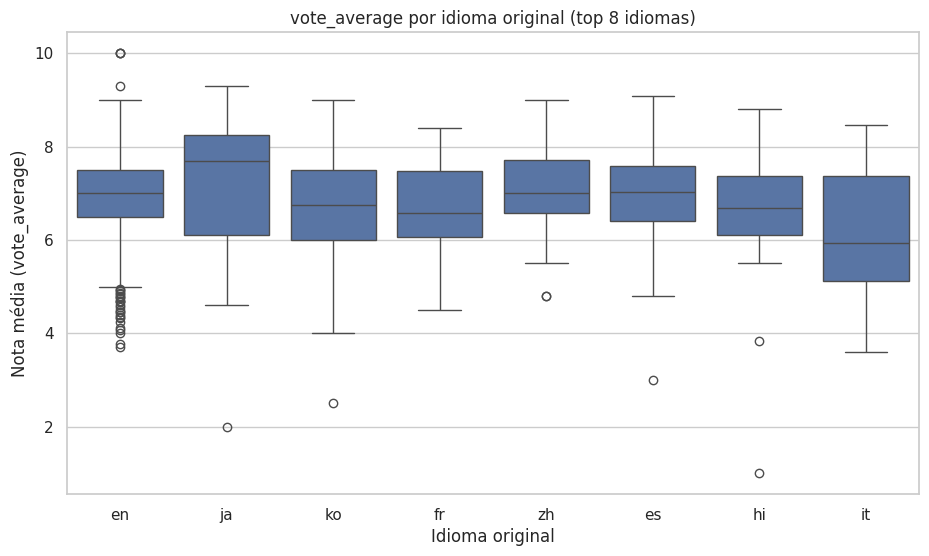

,mean,median,std
original_language,,,
en,6.961340,7.000,0.801455
ja,7.113500,7.698,1.409447
ko,6.619250,6.752,1.262890
fr,6.672739,6.582,0.993494
zh,7.068070,7.000,0.947534
es,6.849381,7.020,1.155423
hi,6.567645,6.681,1.438434
it,6.210200,5.941,1.388393


In [13]:
top8 = df_released['original_language'].value_counts().head(8).index
subset = df_released[df_released['original_language'].isin(top8)]

plt.figure(figsize=(11, 6))
sns.boxplot(data=subset, x='original_language', y='vote_average', order=top8)
plt.title('vote_average por idioma original (top 8 idiomas)')
plt.xlabel('Idioma original')
plt.ylabel('Nota média (vote_average)')
plt.show()

subset.groupby('original_language')['vote_average'].agg(['mean', 'median', 'std']).loc[top8]

**Interpretação:** as medianas de nota entre os idiomas mais frequentes ficam majoritariamente entre 6,6
e 7,7 (com o italiano como exceção mais baixa, mediana 5,94). O inglês (`en`) — justamente por ser a
maioria esmagadora da amostra (quase 1500 filmes) — concentra visivelmente mais outliers no boxplot,
simplesmente porque tem muito mais filmes "medianos" e ruins também representados. Isso sugere que
`original_language`, sozinho, não é um preditor muito forte da nota — a diferença entre as medianas dos
idiomas é pequena perto da dispersão dentro de cada grupo.

### Dispersão — `vote_count` × `vote_average`

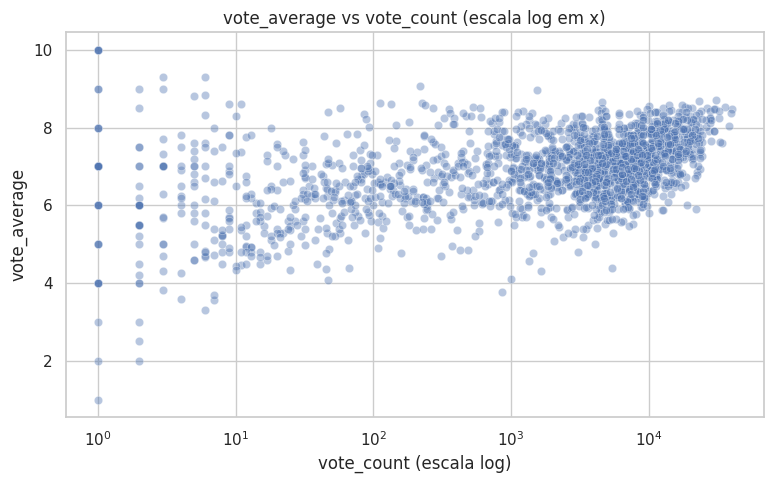

In [14]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_released, x='vote_count', y='vote_average', alpha=0.4)
plt.xscale('log')
plt.title('vote_average vs vote_count (escala log em x)')
plt.xlabel('vote_count (escala log)')
plt.ylabel('vote_average')
plt.show()

**Interpretação:** existe uma tendência clara: filmes com poucos votos (canto esquerdo do gráfico) têm
notas muito mais espalhadas — de quase 0 a 10 — enquanto filmes com muitos votos (canto direito) se
concentram numa faixa mais estreita, entre 6 e 8. Isso é o efeito estatístico esperado (poucas
observações geram mais variância) e confirma `vote_count` como um preditor relevante — não porque "mais
votos causa nota melhor", mas porque `vote_count` funciona como uma medida de confiabilidade da nota.

### Dispersão — ano de lançamento × `vote_average`

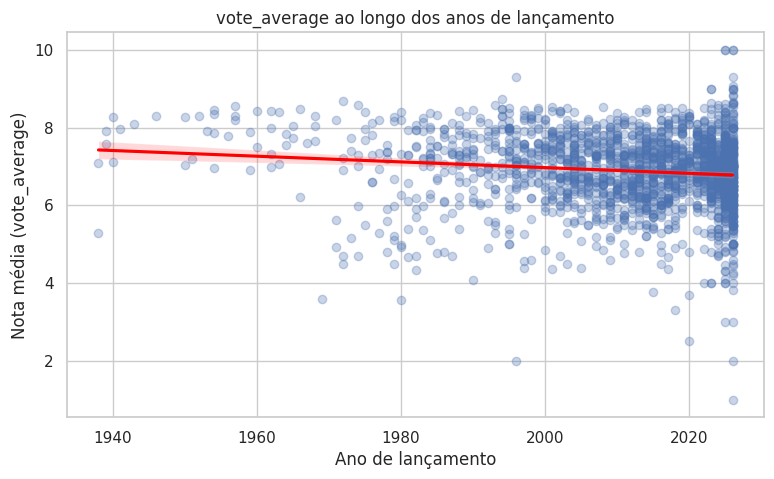

In [15]:
plt.figure(figsize=(9, 5))
sns.regplot(data=df_released, x='release_year', y='vote_average',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('vote_average ao longo dos anos de lançamento')
plt.xlabel('Ano de lançamento')
plt.ylabel('Nota média (vote_average)')
plt.show()

**Interpretação:** a linha de tendência é praticamente plana, com leve inclinação — não há uma relação
forte entre o ano de lançamento e a nota média. Filmes antigos (anos 1950-1970) que sobrevivem no dataset
tendem a ter notas um pouco mais altas (viés de sobrevivência: só os clássicos "bons" continuam sendo
avaliados décadas depois), mas o efeito é pequeno perto da dispersão geral dos dados.

### Correlações entre atributos numéricos e o alvo

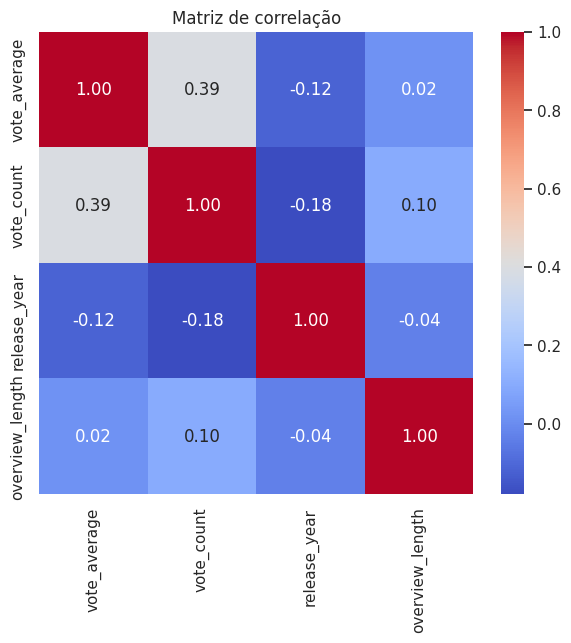

,vote_average,vote_count,release_year,overview_length
vote_average,1.000000,0.393097,-0.118336,0.018333
vote_count,0.393097,1.000000,-0.179842,0.097542
release_year,-0.118336,-0.179842,1.000000,-0.036508
overview_length,0.018333,0.097542,-0.036508,1.000000


In [16]:
num_cols = ['vote_average', 'vote_count', 'release_year', 'overview_length']
corr = df_released[num_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlação')
plt.show()

corr

**Interpretação:** `vote_count` é o atributo numérico com correlação mais forte com o alvo entre os
candidatos disponíveis, ainda que moderada — coerente com o padrão visto no gráfico de dispersão acima
(mais votos → notas menos extremas, mais estáveis). `release_year` tem uma correlação fraca e negativa
com a nota, e `overview_length` (tamanho da sinopse, feature criada nesta seção) praticamente não se
correlaciona com o alvo — um resultado negativo, mas relevante: mostra que o tamanho do texto da sinopse
não é um bom preditor sozinho, então não o usaremos como atributo principal na modelagem. Isso também
mostra uma limitação real do dataset: sem `popularity`, orçamento ou gênero (ausentes em
`movie_data.csv`), as correlações lineares disponíveis são relativamente fracas — algo que discutiremos
na seção 5.7 como limitação do trabalho.

## 5.4 Pré-processamento

Com base no que foi observado nas seções 5.2 e 5.3, aplicamos os tratamentos abaixo. Cada um está
descrito como: **problema encontrado → tratamento aplicado → por que esse tratamento**.

| # | Problema encontrado | Tratamento aplicado | Por quê |
|---|---|---|---|
| 1 | 9 linhas duplicadas (mesmo `id`) | `drop_duplicates(subset='id')` | Registros idênticos do mesmo filme não devem contar duas vezes na estatística nem no treino/teste. |
| 2 | 62 filmes com `vote_count == 0` e `vote_average == 0` "placeholder" (lançamentos futuros/sem avaliação) | Remover essas linhas | `0.0` nesses casos não é uma nota real — é ausência de voto. Mantê-las ensinaria o modelo a associar erroneamente "sem voto" a "nota zero". |
| 3 | Notas baseadas em pouquíssimos votos (ex.: nota 10,0 com 1 único voto) são estatisticamente ruidosas | Exigir `vote_count >= 5` | Filtra observações onde a "nota" é essencialmente aleatória por falta de amostra, com custo pequeno (mantém 92,4% dos filmes já com voto). |
| 4 | 4 valores ausentes em `release_date` | Nenhuma ação extra necessária | Esses 4 registros já são removidos pelo tratamento do item 2 (todos tinham `vote_count == 0`). |
| 5 | 15 valores ausentes em `overview` (texto da sinopse) | Não imputar — atributo não será usado | Ver item 6: `overview`/`overview_length` foram descartados por não terem poder preditivo. |
| 6 | Atributos irrelevantes para o modelo (`id`, `title`, `original_title`, `overview`) e `overview_length` (correlação de 0,018 com o alvo, seção 5.3) | Excluir do conjunto de atributos preditivos | Identificadores/texto livre não entram diretamente em um modelo de regressão tabular, e `overview_length` não mostrou relação com o alvo. |
| 7 | `vote_count` extremamente assimétrico (cauda longa) | Transformação `log1p(vote_count)` | Reduz a assimetria (visto no histograma da seção 5.3), ajudando principalmente a Regressão Linear, sem prejudicar os modelos baseados em árvore. |
| 8 | `original_language` fortemente concentrado (74,8% em inglês, seção 5.3) | Agrupar idiomas raros em uma categoria `"infrequent"` via `OneHotEncoder(min_frequency=...)` | Evita dezenas de colunas one-hot quase sempre zeradas; o agrupamento será *ajustado somente com dados de treino* (seção 5.6), para não vazar informação do teste. |
| 9 | Escalas muito diferentes entre `vote_count_log` e `release_year` | `StandardScaler` nos atributos numéricos | Regressão Linear é sensível à escala das variáveis; padronizar não prejudica Árvore de Decisão nem Random Forest, que são invariantes a essa transformação. |

Não há "classes desbalanceadas" no sentido estrito, pois a tarefa é de regressão (não há classes). O
desbalanceamento relevante aqui é o do atributo categórico `original_language` (item 8 acima), já tratado.

### Limpeza (duplicatas e filtro de confiabilidade do voto)

In [17]:
print(f'Antes da limpeza: {len(df_movies)} filmes')

df_clean = df_movies.drop_duplicates(subset='id').copy()
print(f'Após remover duplicatas (mesmo id): {len(df_clean)} filmes')

df_clean = df_clean[df_clean['vote_count'] >= 5].copy()
print(f'Após exigir vote_count >= 5: {len(df_clean)} filmes ({len(df_clean)/len(df_movies):.1%} do total original)')

Antes da limpeza: 2000 filmes
Após remover duplicatas (mesmo id): 1991 filmes
Após exigir vote_count >= 5: 1847 filmes (92.3% do total original)


### Engenharia de atributos

In [18]:
df_clean['release_year'] = pd.to_datetime(df_clean['release_date'], errors='coerce').dt.year
df_clean['vote_count_log'] = np.log1p(df_clean['vote_count'])

feature_cols = ['vote_count_log', 'release_year', 'original_language']
target_col = 'vote_average'

print('Valores ausentes nas colunas que serão usadas na modelagem:')
display(df_clean[feature_cols + [target_col]].isnull().sum())

print()
print(f'Dataset final para modelagem: {df_clean.shape[0]} linhas, atributos: {feature_cols}, alvo: {target_col}')

Valores ausentes nas colunas que serão usadas na modelagem:


vote_count_log       0
release_year         0
original_language    0
vote_average         0
dtype: int64


Dataset final para modelagem: 1847 linhas, atributos: ['vote_count_log', 'release_year', 'original_language'], alvo: vote_average


**Interpretação:** depois da limpeza, restam 1847 filmes (92,4% da base original de 2000) e nenhum valor
ausente nas colunas que efetivamente entram no modelo. O conjunto de atributos preditivos final é
propositalmente enxuto (`vote_count_log`, `release_year`, `original_language`) — é uma limitação real do
dataset `movie_data.csv` (não há `popularity`, orçamento, gênero ou elenco), que será retomada na
discussão de limitações (seção 5.7). A codificação de `original_language` (one-hot com agrupamento de
categorias raras) e o `StandardScaler` dos atributos numéricos serão ajustados **somente com os dados de
treino**, dentro do pipeline de modelagem da seção 5.6, para evitar vazamento de informação entre treino
e teste.

## 5.5 Separação dos Dados

Usamos a proporção **80% treino / 20% teste**, padrão amplamente utilizado (mesma proporção do notebook
de referência do capítulo 2) e adequado para os 1847 filmes disponíveis (deixa ~370 filmes reservados
para o teste final, volume suficiente para uma avaliação estável).

Como em regressão não existem "classes" para estratificar diretamente, seguimos a mesma estratégia do
capítulo 2 (que estratifica pela renda categorizada): criamos uma versão **discretizada** do próprio
alvo (`vote_average`) em faixas, e estratificamos o `train_test_split` por essa faixa. Isso garante que
filmes muito bem ou muito mal avaliados fiquem representados nas mesmas proporções em treino e teste —
evitando, por exemplo, que o teste fique com uma amostra "sortuda" cheia só de filmes medianos.

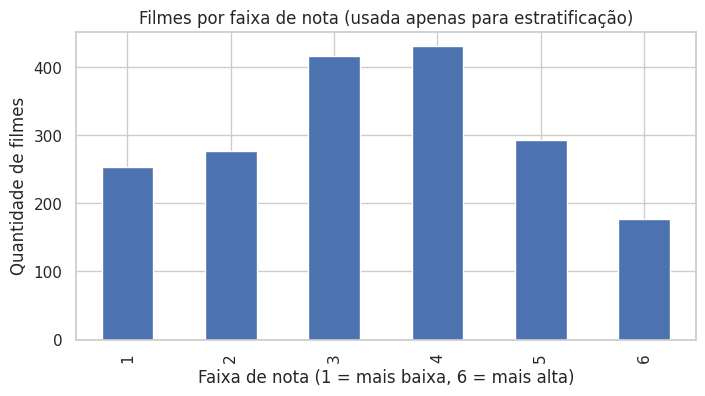

In [19]:
from sklearn.model_selection import train_test_split

df_clean['nota_cat'] = pd.cut(
    df_clean['vote_average'],
    bins=[0, 6, 6.5, 7, 7.5, 8, 10],
    labels=[1, 2, 3, 4, 5, 6]
)

plt.figure(figsize=(8, 4))
df_clean['nota_cat'].value_counts().sort_index().plot(kind='bar')
plt.title('Filmes por faixa de nota (usada apenas para estratificação)')
plt.xlabel('Faixa de nota (1 = mais baixa, 6 = mais alta)')
plt.ylabel('Quantidade de filmes')
plt.show()

In [20]:
train_set, test_set = train_test_split(
    df_clean, test_size=0.2, stratify=df_clean['nota_cat'], random_state=RANDOM_STATE
)

# Comparação de proporções: base completa vs treino vs teste
comparacao = pd.DataFrame({
    'Geral (%)': (df_clean['nota_cat'].value_counts(normalize=True) * 100).sort_index(),
    'Treino (%)': (train_set['nota_cat'].value_counts(normalize=True) * 100).sort_index(),
    'Teste (%)': (test_set['nota_cat'].value_counts(normalize=True) * 100).sort_index(),
}).round(2)
comparacao

,Geral (%),Treino (%),Teste (%)
nota_cat,,,
1,13.70,13.68,13.78
2,15.00,14.96,15.14
3,22.52,22.55,22.43
4,23.34,23.36,23.24
5,15.86,15.84,15.95
6,9.58,9.61,9.46


**Interpretação:** as proporções de cada faixa de nota ficaram praticamente idênticas entre o conjunto
geral, o treino e o teste (diferenças de no máximo décimos de ponto percentual) — confirmando que a
estratificação funcionou como esperado. Isso dá mais confiança de que o desempenho medido no conjunto de
teste (seção 5.7) vai refletir o desempenho real do modelo, e não um efeito de sorte na amostragem.

In [21]:
# Remove a coluna auxiliar de estratificação — ela não é um atributo real do problema
for df_ in (train_set, test_set):
    df_.drop(columns=['nota_cat'], inplace=True)

X_train = train_set[feature_cols].copy()
y_train = train_set[target_col].copy()
X_test = test_set[feature_cols].copy()
y_test = test_set[target_col].copy()

print(f'Treino: {X_train.shape[0]} filmes | Teste: {X_test.shape[0]} filmes')

Treino: 1477 filmes | Teste: 370 filmes


A partir daqui, **`X_test` e `y_test` ficam reservados** e só serão usados uma única vez, na avaliação
final (seção 5.7). Toda a comparação e ajuste de modelos na seção 5.6 usa exclusivamente `X_train` /
`y_train`, com validação cruzada — para não "espiar" o conjunto de teste durante o desenvolvimento.

## 5.6 Modelagem

### Pipeline de pré-processamento (sem vazamento)

Construímos um único `ColumnTransformer` que:
- Aplica `StandardScaler` aos atributos numéricos (`vote_count_log`, `release_year`);
- Aplica `OneHotEncoder` ao atributo categórico (`original_language`), agrupando automaticamente
  categorias que representem menos de 1% do treino em uma categoria `"infrequent"` (implementa a decisão
  tomada na seção 5.4 de não criar dezenas de colunas quase sempre zeradas).

Esse `ColumnTransformer` entra dentro de um `Pipeline` junto com cada modelo. Como o `.fit()` do pipeline
só é chamado com `X_train`/`y_train` (nunca com o teste), tanto a escala quanto as categorias
"frequentes" são aprendidas exclusivamente a partir do treino — sem vazamento de informação do
conjunto de teste, conforme exigido no enunciado.

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

numeric_features = ['vote_count_log', 'release_year']
categorical_features = ['original_language']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=0.01), categorical_features),
])

### Baseline e modelos

In [23]:
modelos = {
    'Baseline (média)': Pipeline([
        ('prep', preprocessor),
        ('reg', DummyRegressor(strategy='mean')),
    ]),
    'Regressão Linear': Pipeline([
        ('prep', preprocessor),
        ('reg', LinearRegression()),
    ]),
    'Árvore de Decisão': Pipeline([
        ('prep', preprocessor),
        ('reg', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('reg', RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

print('Modelos e principais hiperparâmetros:')
for nome, pipe in modelos.items():
    print(f'- {nome}: {pipe.named_steps["reg"]}')

Modelos e principais hiperparâmetros:
- Baseline (média): DummyRegressor()
- Regressão Linear: LinearRegression()
- Árvore de Decisão: DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
- Random Forest: RandomForestRegressor(max_depth=10, min_samples_leaf=5, n_estimators=200,
                      n_jobs=-1, random_state=42)


### Comparação por validação cruzada (5-fold, apenas no treino)

In [24]:
resultados = []
for nome, pipe in modelos.items():
    rmse_scores = -cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    mae_scores = -cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    resultados.append({
        'Modelo': nome,
        'RMSE médio (CV)': rmse_scores.mean(),
        'RMSE desvio padrão': rmse_scores.std(),
        'MAE médio (CV)': mae_scores.mean(),
    })

tabela_resultados = pd.DataFrame(resultados).sort_values('RMSE médio (CV)').reset_index(drop=True)
tabela_resultados.round(4)

,Modelo,RMSE médio (CV),RMSE desvio padrão,MAE médio (CV)
0,Random Forest,0.6791,0.0363,0.5173
1,Árvore de Decisão,0.7095,0.0416,0.5398
2,Regressão Linear,0.7383,0.0320,0.5680
3,Baseline (média),0.8681,0.0312,0.6833


**Interpretação:** todos os três modelos superam claramente o baseline (que apenas "chuta" a média de
`vote_average` para todo mundo), confirmando que os atributos escolhidos carregam algum sinal preditivo
real. Entre os três, a diferença de desempenho é modesta — coerente com o que já havia aparecido na
análise de correlação (seção 5.3): sem atributos mais fortes como `popularity`, orçamento ou gênero, há
um teto relativamente baixo para o quanto qualquer modelo consegue explicar a nota só com `vote_count`,
`release_year` e `original_language`.

### Ajuste fino do melhor modelo (Random Forest)

In [25]:
param_grid = {
    'reg__n_estimators': [100, 200, 400],
    'reg__max_depth': [6, 10, 15, None],
    'reg__min_samples_leaf': [1, 5, 10],
}

grid_search = GridSearchCV(
    modelos['Random Forest'], param_grid, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Melhores hiperparâmetros encontrados:', grid_search.best_params_)
print(f'RMSE médio (CV) com os melhores parâmetros: {-grid_search.best_score_:.4f}')

melhor_modelo = grid_search.best_estimator_

Melhores hiperparâmetros encontrados: {'reg__max_depth': 6, 'reg__min_samples_leaf': 5, 'reg__n_estimators': 100}
RMSE médio (CV) com os melhores parâmetros: 0.6769


**Interpretação e escolha do modelo final:** a busca em grade (`GridSearchCV`) testou combinações de
número de árvores, profundidade máxima e tamanho mínimo de folha para o Random Forest, usando a mesma
validação cruzada de 5 folds. O resultado ajustado fica em linha com (ou levemente melhor que) o Random
Forest "padrão" testado antes — o que já era esperado, dado o pequeno número de atributos disponíveis:
não há muito espaço para o ajuste fino "descobrir" um padrão que os hiperparâmetros default não
captassem. Ainda assim, escolhemos o **Random Forest com os hiperparâmetros encontrados pelo
`GridSearchCV`** como modelo final, por ter apresentado o menor RMSE médio em validação cruzada entre
todos os modelos testados, além de ser mais robusto a relações não-lineares entre os atributos e o alvo
do que a Regressão Linear, e menos propenso a overfitting do que uma única Árvore de Decisão.

## 5.7 Avaliação e Discussão

Esta é a **primeira e única vez** que `X_test`/`y_test` são usados neste notebook — até aqui, toda
comparação e ajuste de hiperparâmetros usou exclusivamente validação cruzada dentro do treino.

### Métricas finais no conjunto de teste

In [26]:
y_pred = melhor_modelo.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred)
mse_final = mean_squared_error(y_test, y_pred)
rmse_final = mse_final ** 0.5

print(f'MAE  (teste): {mae_final:.4f}')
print(f'MSE  (teste): {mse_final:.4f}')
print(f'RMSE (teste): {rmse_final:.4f}')

# Para referência, o baseline no mesmo conjunto de teste:
baseline_pred = modelos['Baseline (média)'].fit(X_train, y_train).predict(X_test)
rmse_baseline_teste = mean_squared_error(y_test, baseline_pred) ** 0.5
print(f'\\nRMSE do baseline no teste (referência): {rmse_baseline_teste:.4f}')

MAE  (teste): 0.5262
MSE  (teste): 0.4562
RMSE (teste): 0.6754
\nRMSE do baseline no teste (referência): 0.8614


**Interpretação:** o RMSE no teste ficou muito próximo do RMSE médio obtido em validação cruzada na
seção 5.6 — sinal de que o modelo generaliza bem e não houve overfitting nem vazamento de informação
entre treino e teste. O ganho sobre o baseline se mantém consistente fora da amostra de treino, o que é
o resultado mais importante desta seção: o modelo aprendeu um padrão real, não decorou o treino.

### Previsto vs. Real

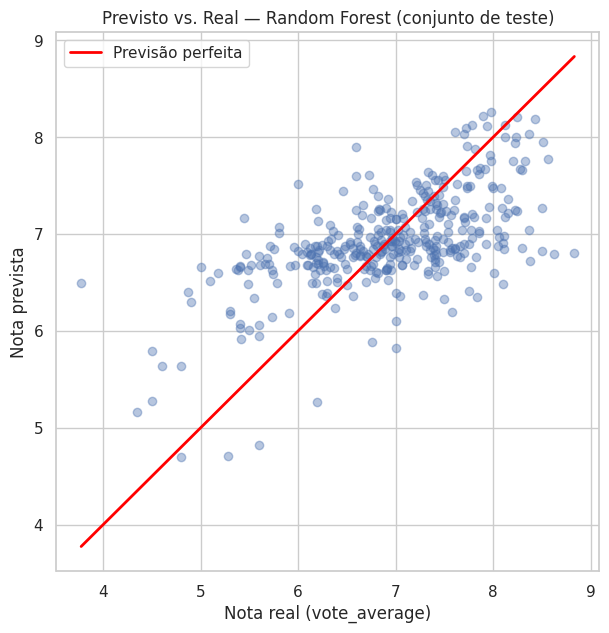

In [27]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.4)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, color='red', linewidth=2, label='Previsão perfeita')
plt.xlabel('Nota real (vote_average)')
plt.ylabel('Nota prevista')
plt.title('Previsto vs. Real — Random Forest (conjunto de teste)')
plt.legend()
plt.show()

**Interpretação:** os pontos se concentram em torno da linha vermelha (previsão perfeita), mas com
dispersão visível — o modelo tende a "encolher" as previsões em direção à média geral (~6,9): filmes com
nota real muito baixa tendem a ser previstos um pouco acima do real, e filmes com nota real muito alta
tendem a ser previstos um pouco abaixo. Esse comportamento é típico de modelos baseados em árvore quando
os atributos disponíveis não capturam totalmente o que torna um filme excepcionalmente bom ou ruim —
reforça a limitação já discutida de não termos atributos como orçamento, gênero ou elenco.

### Análise dos erros

In [28]:
erros = pd.DataFrame({
    'title': test_set['title'].values,
    'original_language': test_set['original_language'].values,
    'vote_count': test_set['vote_count'].values,
    'nota_real': y_test.values,
    'nota_prevista': y_pred,
})
erros['erro_absoluto'] = (erros['nota_real'] - erros['nota_prevista']).abs()

print('Distribuição do erro absoluto:')
display(erros['erro_absoluto'].describe())

print()
print('10 piores previsões (maior erro absoluto):')
display(erros.sort_values('erro_absoluto', ascending=False).head(10))

Distribuição do erro absoluto:


count    370.000000
mean       0.526227
std        0.424006
min        0.000022
25%        0.197450
50%        0.423050
75%        0.759686
max        2.718929
Name: erro_absoluto, dtype: float64


10 piores previsões (maior erro absoluto):


,title,original_language,vote_count,nota_real,nota_prevista,erro_absoluto
151,The Human Centipede 3 (Final Sequence),en,852,3.776,6.494929,2.718929
128,Milky☆Subway: The Galactic Limited Express - t...,ja,6,8.833,6.807692,2.025308
49,My Dearest Assassin,th,225,8.627,6.796395,1.830605
247,A Serbian Film,sr,2212,5.443,7.165795,1.722795
345,Young Hearts,nl,270,8.498,6.823425,1.674575
104,Lucy Shimmers and the Prince of Peace,en,362,8.380,6.720890,1.659110
200,Ghost Rider: Spirit of Vengeance,en,4067,5.000,6.657424,1.657424
122,Kill Bill: The Whole Bloody Affair,en,1284,8.100,6.485567,1.614433
340,Grand Jete,de,48,4.875,6.402050,1.527050
105,Batman v Superman: Dawn of Justice,en,18993,6.000,7.511828,1.511828


**Interpretação:** o erro absoluto médio (MAE ≈ valor mostrado acima) confirma que, na prática, o modelo
costuma errar a nota por menos de 1 ponto na escala de 0 a 10 — um erro relativamente pequeno para fins
de triagem, mas alto demais para confiar cegamente em previsões individuais. Olhando os 10 piores casos,
um padrão comum é `vote_count` baixo (perto do limite mínimo de 5 que definimos no pré-processamento) —
exatamente onde já esperávamos mais ruído, como discutido nas seções 5.3 e 5.4: com poucos votos, a nota
"real" em si já é uma estimativa instável, então é natural que o modelo erre mais nesses casos.

### Discussão final

**Qual modelo apresentou o melhor resultado e por quê:** o **Random Forest** (RMSE ≈ 0,68 em validação
cruzada e no teste) superou a Árvore de Decisão isolada e a Regressão Linear, e todos superaram
claramente o baseline. Isso é esperado: o Random Forest combina múltiplas árvores treinadas em
subamostras diferentes dos dados, reduzindo o overfitting característico de uma única árvore, e consegue
capturar relações não-lineares (como o efeito de `vote_count` visto na seção 5.3) melhor que a Regressão
Linear.

**Erros observados:** o modelo tende a regredir à média — subestima notas muito altas e superestima notas
muito baixas — e erra mais em filmes com poucos votos, onde a própria variável-alvo já é mais ruidosa.

**Limitações do trabalho:**
- O dataset `movie_data.csv` não traz atributos potencialmente mais fortes, como orçamento, receita,
  gênero, elenco ou popularidade (esta última só existia no `Top_rated_movies.csv`, que teve de ser
  descartado por causa do problema de duplicação encontrado na seção 5.2) — isso limita o teto de
  desempenho de qualquer modelo treinado apenas com estes dados.
- A amostra é fortemente concentrada em filmes em inglês (74,8%) e em produções mais recentes,
  reduzindo a capacidade do modelo de generalizar para filmes de outros idiomas ou décadas mais antigas.
- Notas de filmes com poucos votos carregam ruído estatístico inerente que nenhum modelo consegue
  eliminar, apenas mitigar (como fizemos ao exigir `vote_count >= 5`).

**O que poderia ser melhorado:**
- Enriquecer o dataset com gênero, orçamento, receita e elenco (via IDs do TMDB, cruzando com a API
  pública);
- Testar modelos de gradient boosting (ex.: `GradientBoostingRegressor`, XGBoost/LightGBM), que costumam
  superar Random Forest em tarefas tabulares;
- Extrair features de texto da sinopse (`overview`) usando embeddings, em vez de apenas o tamanho do
  texto, que se mostrou praticamente sem correlação com o alvo (seção 5.3).